# Bulk RNA-seq TPM vs spatial pseudo-bulk CPM

Compare bulk RNA-seq TPM with spatial pseudo-bulk CPM by sample and platform. Genes are matched by symbol, lightly filtered (`TPM > 1`, `CPM > 1`), and compared with Spearman correlation.

## Setup

Aim: define paths, samples, platforms, thresholds, and plotting colours.

In [13]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spatialdata as sd
from scipy.stats import spearmanr, ttest_rel

from merxen.qc.gene_comparison import apply_dataset_filter

MERXEN_ROOT = Path(os.environ.get("MERXEN_ROOT", Path.cwd().parent)).resolve()
BULKSEQ = MERXEN_ROOT / "bulkseq-data"
RESULTS = MERXEN_ROOT / "results"
FIGURES = RESULTS / "bulkseq_tpm_spatial_cpm_correlation"
FIGURES.mkdir(parents=True, exist_ok=True)

FPKM_TSV = BULKSEQ / "MerXenRNAseq.gene.FPKM.txt"
SPATIAL_ZARR = Path("latest") / "latest_spatialdata.zarr"
GENE_COLUMNS = ["gene", "feature_name", "target", "gene_name"]

SAMPLE_TO_FPKM_COL = {
    "P5011": "S1_5011",
    "P1212": "S2_1212",
    "P7113": "S3_7113",
    "P7513": "S4_7513",
}
SAMPLES = list(SAMPLE_TO_FPKM_COL)
PLATFORMS = {"Xenium": "xenium", "Merscope": "merscope"}
PLATFORM_COLORS = {"Xenium": "#0072B2", "Merscope": "#D55E00"}

MIN_TPM = 1.0
MIN_CPM = 1.0

## Bulk FPKM to TPM

Aim: convert bulk RNA-seq FPKM profiles to comparable TPM profiles.

In [2]:
fpkm = pd.read_csv(FPKM_TSV, sep="	")
fpkm = fpkm[fpkm["Geneid"].astype(str).str.startswith("ENSG")].copy()
fpkm["symbol"] = fpkm["Gene.name"].astype(str).str.strip()
fpkm = fpkm[fpkm["symbol"].notna() & (fpkm["symbol"] != "")]

bulk_fpkm = fpkm[["symbol", *SAMPLE_TO_FPKM_COL.values()]].groupby("symbol").sum()
bulk_tpm = bulk_fpkm.div(bulk_fpkm.sum(axis=0), axis=1) * 1_000_000
bulk_tpm = bulk_tpm.rename(columns={v: k for k, v in SAMPLE_TO_FPKM_COL.items()})

bulk_tpm_summary = pd.DataFrame(
    {
        "spatial_sample": bulk_tpm.columns,
        "n_genes": len(bulk_tpm),
        "tpm_sum": bulk_tpm.sum().to_numpy(),
        "n_genes_tpm_gt_1": (bulk_tpm > MIN_TPM).sum().to_numpy(),
    }
)
bulk_tpm_summary

,spatial_sample,n_genes,tpm_sum,n_genes_tpm_gt_1
0,P5011,41105,1000000.0,17209
1,P1212,41105,1000000.0,12774
2,P7113,41105,1000000.0,17296
3,P7513,41105,1000000.0,19619


## Spatial pseudo-bulk CPM

Aim: count spatial transcripts by gene and normalise each sample-platform profile to CPM.

In [3]:
spatial_counts = {}
spatial_cpm = {}
summary_rows = []

for sample in SAMPLES:
    for platform, folder in PLATFORMS.items():
        zarr_path = RESULTS / sample / folder / SPATIAL_ZARR
        sdata = sd.read_zarr(zarr_path)
        points_key = next((k for k in sdata.points if "transcript" in str(k).lower()), None)
        if points_key is None:
            points_key = next(iter(sdata.points))
        points = sdata.points[points_key]
        gene_col = next((col for col in GENE_COLUMNS if col in points.columns), None)
        if gene_col is None:
            raise KeyError(f"No gene column found in {zarr_path}")

        if hasattr(points, "npartitions"):
            counts = points[[gene_col]].groupby(gene_col).size().compute()
        else:
            counts = points.groupby(gene_col).size()
        counts.index = counts.index.astype(str).str.strip()
        counts = counts[(counts.index != "") & (counts.index != "nan")]
        counts = counts.groupby(level=0).sum().astype(float)
        counts = apply_dataset_filter(counts, platform)

        cpm = counts / counts.sum() * 1_000_000
        spatial_counts[(sample, platform)] = counts
        spatial_cpm[(sample, platform)] = cpm.rename("spatial_cpm")
        summary_rows.append(
            {
                "spatial_sample": sample,
                "platform": platform,
                "points_key": str(points_key),
                "gene_column": gene_col,
                "n_genes": len(counts),
                "total_raw_counts": counts.sum(),
                "cpm_sum": cpm.sum(),
                "n_genes_cpm_gt_1": (cpm > MIN_CPM).sum(),
            }
        )

spatial_cpm_summary = pd.DataFrame(summary_rows)
spatial_cpm_summary

,spatial_sample,platform,points_key,gene_column,n_genes,total_raw_counts,cpm_sum,n_genes_cpm_gt_1
0,P5011,Xenium,transcripts,gene,505,9367400.0,1000000.0,332
1,P5011,Merscope,transcripts,gene,350,3240646.0,1000000.0,350
2,P1212,Xenium,transcripts,gene,511,10346716.0,1000000.0,351
3,P1212,Merscope,transcripts,gene,350,5917098.0,1000000.0,350
4,P7113,Xenium,transcripts,gene,507,14992569.0,1000000.0,337
5,P7113,Merscope,transcripts,gene,350,9361152.0,1000000.0,350
6,P7513,Xenium,transcripts,gene,528,15244352.0,1000000.0,343
7,P7513,Merscope,transcripts,gene,350,24832228.0,1000000.0,350


## Spearman by sample and platform

Aim: align bulk and spatial genes, filter low abundance genes, and compute per-sample correlations.

In [4]:
aligned_expression = {}
correlation_rows = []

for sample in SAMPLES:
    bulk = bulk_tpm[sample].rename("bulk_tpm").rename_axis("symbol").reset_index()
    for platform in PLATFORMS:
        spatial = spatial_cpm[(sample, platform)].rename_axis("symbol").reset_index()
        aligned = bulk.merge(spatial, on="symbol")
        filtered = aligned[(aligned["bulk_tpm"] > MIN_TPM) & (aligned["spatial_cpm"] > MIN_CPM)]
        rho, p_value = spearmanr(filtered["bulk_tpm"], filtered["spatial_cpm"])

        aligned_expression[(sample, platform)] = filtered
        correlation_rows.append(
            {
                "spatial_sample": sample,
                "platform": platform,
                "n_genes_intersection": len(aligned),
                "n_genes_after_filter": len(filtered),
                "spearman_rho": rho,
                "spearman_p_value": p_value,
                "bulk_tpm_threshold": MIN_TPM,
                "spatial_cpm_threshold": MIN_CPM,
            }
        )

correlation_summary = pd.DataFrame(correlation_rows)
correlation_summary

,spatial_sample,platform,n_genes_intersection,n_genes_after_filter,spearman_rho,spearman_p_value,bulk_tpm_threshold,spatial_cpm_threshold
0,P5011,Xenium,296,258,0.629395,7.177389e-30,1.0,1.0
1,P5011,Merscope,299,260,0.503027,4.415393e-18,1.0,1.0
2,P1212,Xenium,296,199,0.574940,6.654023e-19,1.0,1.0
3,P1212,Merscope,299,200,0.464337,4.339196e-12,1.0,1.0
4,P7113,Xenium,296,249,0.649078,3.574978e-31,1.0,1.0
5,P7113,Merscope,299,251,0.574374,1.971134e-23,1.0,1.0
6,P7513,Xenium,296,267,0.717227,1.832162e-43,1.0,1.0
7,P7513,Merscope,299,269,0.641702,1.294429e-32,1.0,1.0


## Spearman summary by platform

Aim: compare platform-level correlations across paired tissue samples.

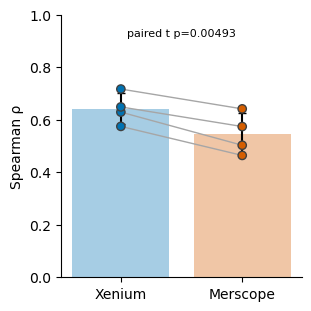

,comparison,n_pairs,mean_difference,t_statistic,p_value
0,Xenium - Merscope,4,0.0968,7.487519,0.004935


In [14]:
platform_names = list(PLATFORMS)
paired_rho = correlation_summary.pivot(
    index="spatial_sample",
    columns="platform",
    values="spearman_rho",
).loc[SAMPLES, platform_names]

t_stat, p_value = ttest_rel(paired_rho["Xenium"], paired_rho["Merscope"])
paired_platform_test = pd.DataFrame(
    [
        {
            "comparison": "Xenium - Merscope",
            "n_pairs": len(paired_rho),
            "mean_difference": (paired_rho["Xenium"] - paired_rho["Merscope"]).mean(),
            "t_statistic": t_stat,
            "p_value": p_value,
        }
    ]
)

fig, ax = plt.subplots(figsize=(3.0, 3.0), constrained_layout=True)
x = np.arange(len(platform_names))
summary_stats = correlation_summary.groupby("platform")["spearman_rho"].agg(["mean", "std"])
ax.bar(
    x,
    summary_stats.loc[platform_names, "mean"],
    yerr=summary_stats.loc[platform_names, "std"],
    color=[PLATFORM_COLORS[p] for p in platform_names],
    alpha=0.35,
    capsize=3,
)

for sample in SAMPLES:
    ax.plot(x, paired_rho.loc[sample], color="0.65", lw=1, zorder=1)
    ax.scatter(
        x,
        paired_rho.loc[sample],
        color=[PLATFORM_COLORS[p] for p in platform_names],
        edgecolor="0.25",
        zorder=2,
    )

ax.text(0.5, 0.95, f"paired t p={p_value:.3g}", transform=ax.transAxes, ha="center", va="top", fontsize=8)
ax.set_xticks(x, platform_names)
ax.set_ylabel("Spearman ρ")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
plt.savefig(FIGURES / "bulk_tpm_spatial_cpm_spearman_summary.png", dpi=300)
plt.savefig(FIGURES / "bulk_tpm_spatial_cpm_spearman_summary.pdf")
plt.show()

paired_platform_test

## Scatter grid

Aim: show bulk-spatial agreement for each sample and platform on log-scaled axes.

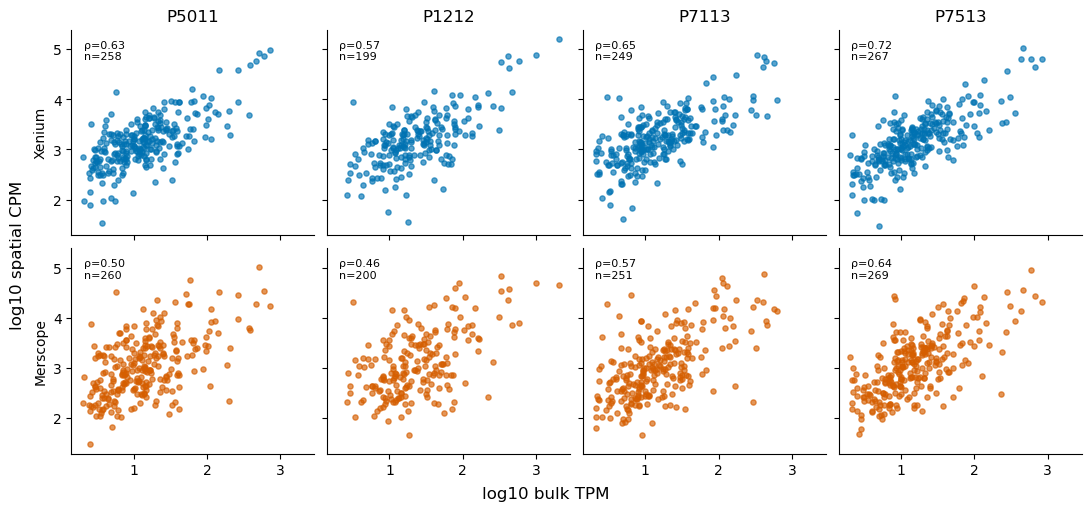

In [11]:
fig, axes = plt.subplots(
    len(PLATFORMS),
    len(SAMPLES),
    figsize=(2.7 * len(SAMPLES), 2.5 * len(PLATFORMS)),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for i, platform in enumerate(PLATFORMS):
    for j, sample in enumerate(SAMPLES):
        ax = axes[i, j]
        data = aligned_expression[(sample, platform)]
        stats = correlation_summary.query("spatial_sample == @sample and platform == @platform").iloc[0]

        ax.scatter(
            np.log10(data["bulk_tpm"] + 1),
            np.log10(data["spatial_cpm"] + 1),
            s=14,
            alpha=0.65,
            color=PLATFORM_COLORS[platform],
        )
        ax.text(
            0.05,
            0.95,
            f"ρ={stats['spearman_rho']:.2f}\nn={int(stats['n_genes_after_filter'])}",
            transform=ax.transAxes,
            va="top",
            fontsize=8,
        )
        if i == 0:
            ax.set_title(sample)
        if j == 0:
            ax.set_ylabel(platform)
        ax.spines[["top", "right"]].set_visible(False)

fig.supxlabel("log10 bulk TPM")
fig.supylabel("log10 spatial CPM")
plt.savefig(FIGURES / "bulk_tpm_spatial_cpm_spearman_scatter_grid.png", dpi=300)
plt.savefig(FIGURES / "bulk_tpm_spatial_cpm_spearman_scatter_grid.pdf")
plt.show()

## Spearman by bulk TPM quartile

Aim: test whether correlation strength changes across bulk expression ranges.

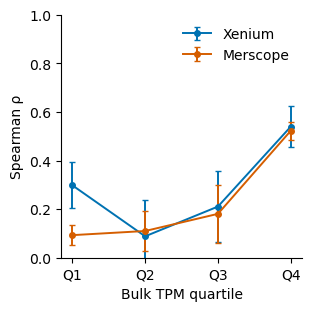

,spatial_sample,platform,bulk_quartile,n_genes,spearman_rho,spearman_p_value
0,P5011,Xenium,Q1,65,0.301948,1.450526e-02
1,P5011,Xenium,Q2,64,0.186337,1.404118e-01
2,P5011,Xenium,Q3,64,0.116575,3.589578e-01
3,P5011,Xenium,Q4,65,0.528322,6.087140e-06
4,P5011,Merscope,Q1,65,0.148689,2.371692e-01
5,P5011,Merscope,Q2,65,0.030464,8.096338e-01
6,P5011,Merscope,Q3,65,0.248495,4.593562e-02
7,P5011,Merscope,Q4,65,0.515341,1.119171e-05
8,P1212,Xenium,Q1,50,0.302857,3.252918e-02
9,P1212,Xenium,Q2,50,-0.020312,8.886521e-01


In [16]:
quartile_labels = [f"Q{i}" for i in range(1, 5)]
quartile_rows = []

for sample in SAMPLES:
    for platform in PLATFORMS:
        data = aligned_expression[(sample, platform)].copy()
        data["bulk_quartile"] = pd.qcut(
            data["bulk_tpm"],
            q=4,
            labels=quartile_labels,
            duplicates="drop",
        )
        for quartile, group in data.groupby("bulk_quartile", observed=False):
            rho, p_value = spearmanr(group["bulk_tpm"], group["spatial_cpm"])
            quartile_rows.append(
                {
                    "spatial_sample": sample,
                    "platform": platform,
                    "bulk_quartile": quartile,
                    "n_genes": len(group),
                    "spearman_rho": rho,
                    "spearman_p_value": p_value,
                }
            )

quartile_spearman = pd.DataFrame(quartile_rows)
quartile_stats = quartile_spearman.groupby(["platform", "bulk_quartile"], observed=False)["spearman_rho"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(3.0, 3.0), constrained_layout=True)
x = np.arange(len(quartile_labels))
for platform in PLATFORMS:
    stats = quartile_stats.loc[platform].reindex(quartile_labels)
    ax.errorbar(
        x,
        stats["mean"],
        yerr=stats["std"],
        marker="o",
        ms=4,
        lw=1.4,
        capsize=2,
        color=PLATFORM_COLORS[platform],
        label=platform,
    )

ax.set_xticks(x, quartile_labels)
ax.set_xlabel("Bulk TPM quartile")
ax.set_ylabel("Spearman ρ")
ax.set_ylim(0, 1)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.savefig(FIGURES / "bulk_tpm_quartile_spearman.png", dpi=300)
plt.savefig(FIGURES / "bulk_tpm_quartile_spearman.pdf")
plt.show()

quartile_spearman

## Spatial CPM sample correlation

Aim: compare spatial pseudo-bulk profiles across samples and platforms.

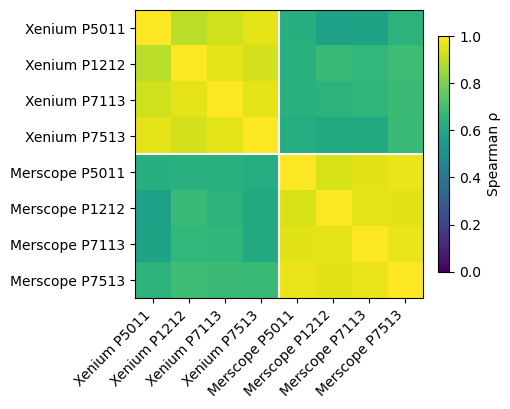

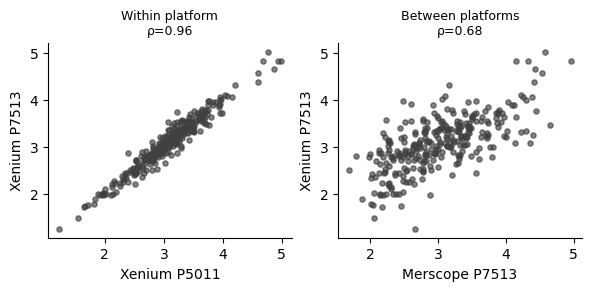

,Xenium P5011,Xenium P1212,Xenium P7113,Xenium P7513,Merscope P5011,Merscope P1212,Merscope P7113,Merscope P7513
Xenium P5011,1.000000,0.895812,0.927083,0.958539,0.627511,0.572904,0.579981,0.647769
Xenium P1212,0.895812,1.000000,0.958806,0.930559,0.635171,0.679294,0.663756,0.690745
Xenium P7113,0.927083,0.958806,1.000000,0.957856,0.636128,0.644900,0.659879,0.683169
Xenium P7513,0.958539,0.930559,0.957856,1.000000,0.620106,0.607545,0.606994,0.677643
Merscope P5011,0.627511,0.635171,0.636128,0.620106,1.000000,0.941115,0.953556,0.970194
Merscope P1212,0.572904,0.679294,0.644900,0.607545,0.941115,1.000000,0.960844,0.955200
Merscope P7113,0.579981,0.663756,0.659879,0.606994,0.953556,0.960844,1.000000,0.971269
Merscope P7513,0.647769,0.690745,0.683169,0.677643,0.970194,0.955200,0.971269,1.000000


In [9]:
profiles = []
for platform in PLATFORMS:
    for sample in SAMPLES:
        label = f"{platform} {sample}"
        profiles.append(spatial_cpm[(sample, platform)].rename(label).rename_axis("symbol"))

spatial_cpm_matrix = pd.concat(profiles, axis=1, join="inner")
profile_corr = spatial_cpm_matrix.corr(method="spearman")

fig, ax = plt.subplots(figsize=(5.0, 4.4), constrained_layout=True)
im = ax.imshow(profile_corr, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(profile_corr)), profile_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(profile_corr)), profile_corr.index)
ax.axhline(len(SAMPLES) - 0.5, color="white", lw=1.5)
ax.axvline(len(SAMPLES) - 0.5, color="white", lw=1.5)
fig.colorbar(im, ax=ax, shrink=0.65, label="Spearman ρ")
plt.savefig(FIGURES / "spatial_cpm_sample_spearman.png", dpi=300)
plt.savefig(FIGURES / "spatial_cpm_sample_spearman.pdf")
plt.show()

example_pairs = {
    "Within platform": ("Xenium P5011", "Xenium P7513"),
    "Between platforms": ("Merscope P7513", "Xenium P7513"),
}

fig, axes = plt.subplots(1, 2, figsize=(5.8, 2.8), constrained_layout=True)
for ax, (label, (x_col, y_col)) in zip(axes, example_pairs.items()):
    rho = profile_corr.loc[x_col, y_col]
    ax.scatter(
        np.log10(spatial_cpm_matrix[x_col] + 1),
        np.log10(spatial_cpm_matrix[y_col] + 1),
        s=14,
        alpha=0.65,
        color="0.25",
    )
    ax.set_title(f"{label}\nρ={rho:.2f}", fontsize=9)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.spines[["top", "right"]].set_visible(False)

plt.savefig(FIGURES / "spatial_cpm_sample_spearman_examples.png", dpi=300)
plt.savefig(FIGURES / "spatial_cpm_sample_spearman_examples.pdf")
plt.show()

profile_corr

## Export tables

Aim: save summary statistics and correlation matrices for reuse.

In [ ]:
correlation_summary.to_csv(FIGURES / "bulk_tpm_spatial_cpm_spearman_summary.csv", index=False)
paired_platform_test.to_csv(FIGURES / "bulk_tpm_spatial_cpm_paired_t_test.csv", index=False)
bulk_tpm_summary.to_csv(FIGURES / "bulk_tpm_summary.csv", index=False)
spatial_cpm_summary.to_csv(FIGURES / "spatial_cpm_summary.csv", index=False)
quartile_spearman.to_csv(FIGURES / "bulk_tpm_quartile_spearman.csv", index=False)
profile_corr.to_csv(FIGURES / "spatial_cpm_sample_spearman.csv")

correlation_summary